2.1
1. 向量点积 a · b；
  -8
2. 矩阵乘法 A × B（结果矩阵的形状？）；
  2*2
  A×B = [[8,5],[1,-2]]
3. 向量 a 的 Frobenius 范数。
  ||a|| = √(2² + (-1)² + 3²) = √(4+1+9) = √14

In [1]:
import numpy as np

# 1. 创建 3x4 随机矩阵
X = np.random.normal(loc=0, scale=1, size=(3, 4))
print("X:\n", X)

# 2. 创建 4x2 全1矩阵
Y = np.ones((4, 2))
print("\nY:\n", Y)

# 3. 矩阵乘法
Z = X @ Y
print("\nZ = X @ Y:\n", Z)

# 4. 输出指定元素
print(f"\nZ[0,1] = {Z[0,1]}")
print(f"Z第2行: {Z[1,:]}")

# 5. Frobenius范数
print(f"\nFrobenius范数: {np.linalg.norm(Z, 'fro')}")

X:
 [[ 0.6911324   1.34217738  0.39935751  0.12784957]
 [-0.49982832  0.79804772  0.67452084 -1.96261071]
 [-0.54202647  0.21494221 -0.28532249  1.90673195]]

Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y:
 [[ 2.56051686  2.56051686]
 [-0.98987047 -0.98987047]
 [ 1.29432519  1.29432519]]

Z[0,1] = 2.560516860764754
Z第2行: [-0.98987047 -0.98987047]

Frobenius范数: 4.292171440266288


3.1
P(+) = 0.99×0.001 + 0.02×0.999 = 0.02097
P(D|+) = (0.99×0.001) / 0.02097 ≈ 0.0472

生成的 1000 个样本均值:
  均值: 0.500020
  标准差: 0.002866
  最小值: 0.489590
  最大值: 0.507979
  前10个均值: [0.4962612  0.49959561 0.49980588 0.50110594 0.50056299 0.50181983
 0.50002056 0.4977812  0.5014888  0.4982529 ]


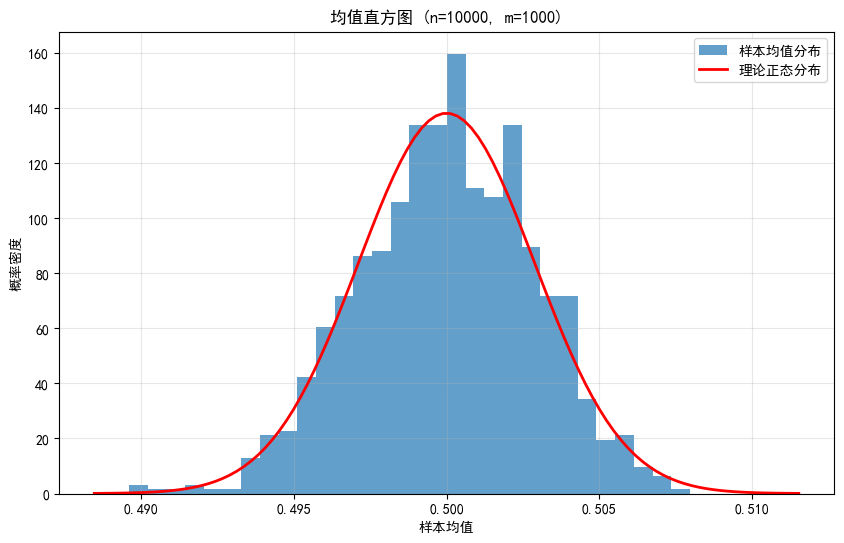


方差对比:
  实际方差: 0.00000822
  理论方差: 0.00000833


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成数据
n = 10000  # 每次抽样数量
m = 1000   # 重复次数

means = np.zeros(m)
for i in range(m):
    samples = np.random.uniform(0, 1, n)
    means[i] = np.mean(samples)

# 输出均值的统计信息
print(f"生成的 {m} 个样本均值:")
print(f"  均值: {np.mean(means):.6f}")
print(f"  标准差: {np.std(means, ddof=1):.6f}")
print(f"  最小值: {np.min(means):.6f}")
print(f"  最大值: {np.max(means):.6f}")
print(f"  前10个均值: {means[:10]}")

# 2. 绘制直方图和理论正态曲线
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')

# 理论正态分布参数
mu = 0.5
sigma = np.sqrt(1/12 / n)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'均值直方图 (n={n}, m={m})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. 计算实际方差
actual_var = np.var(means, ddof=1)
theoretical_var = 1/12 / n

print(f"\n方差对比:")
print(f"  实际方差: {actual_var:.8f}")
print(f"  理论方差: {theoretical_var:.8f}")

4.1
(1) ∂z/∂w₁ = 4(2w₁ + w₂ − 3)
    ∂z/∂w₂ = 2(2w₁ + w₂ − 3)
(2) -4;-2


In [3]:
import torch

# 1. 前向计算
x, w1, w2 = 2.0, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print(f"前向: a={a}, b={b}, L={L}")

# 2. 手动梯度（链式法则）
dL_db = 2 * b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * 1 * x
print(f"手动: ∂L/∂w1={dL_dw1}, ∂L/∂w2={dL_dw2}")

# 3. 自动微分验证
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
L_t = (x * w1_t + w2_t) ** 2
L_t.backward()
print(f"自动: ∂L/∂w1={w1_t.grad}, ∂L/∂w2={w2_t.grad}")

前向: a=3.0, b=3.5, L=12.25
手动: ∂L/∂w1=14.0, ∂L/∂w2=7.0
自动: ∂L/∂w1=14.0, ∂L/∂w2=7.0


5.1
损失函数：
L = (1/n) * Σ(i=1到n) (yᵢ − w xᵢ − b)²

∂L/∂w = -(2/n) * Σ(i=1到n) xᵢ (yᵢ − w xᵢ − b)
∂L/∂b = -(2/n) * Σ(i=1到n) (yᵢ − w xᵢ − b)

In [6]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据
digits = load_digits()
X = digits.data / 16.0
y = digits.target

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. one-hot编码
def to_onehot(y, num_classes=10):
    onehot = np.zeros((len(y), num_classes))
    onehot[np.arange(len(y)), y] = 1
    return onehot

y_train_oh = to_onehot(y_train)
y_test_oh = to_onehot(y_test)

# 3. softmax和交叉熵
def softmax(z):
    exp_z = np.exp(z - z.max(axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-15), axis=1))

# 4. 训练
W = np.random.randn(64, 10) * 0.01
b = np.zeros(10)
lr, batch_size, epochs = 0.1, 32, 50

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_shuf, y_shuf = X_train[idx], y_train_oh[idx]
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuf[i:i+batch_size]
        y_batch = y_shuf[i:i+batch_size]
        
        # 前向
        y_pred = softmax(X_batch @ W + b)
        
        # 反向更新
        W -= lr * (X_batch.T @ (y_pred - y_batch)) / batch_size
        b -= lr * (y_pred - y_batch).mean(axis=0)
    
    if (epoch+1) % 10 == 0:
        loss = cross_entropy(softmax(X_train @ W + b), y_train_oh)
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 5. 测试准确率
y_pred = np.argmax(softmax(X_test @ W + b), axis=1)
acc = np.mean(y_pred == y_test)
print(f"\n测试准确率: {acc*100:.2f}%")

Epoch 10, Loss: 0.4391
Epoch 20, Loss: 0.2945
Epoch 30, Loss: 0.2373
Epoch 40, Loss: 0.2048
Epoch 50, Loss: 0.1835

测试准确率: 96.11%


6.1
对数似然：
lnL = −(n/2)ln(2π) − (n/2)ln(σ²) − (1/(2σ²)) Σ(i=1到n) (xᵢ−μ)²
 
μ 的极大似然估计：
μ̂ = (1/n) Σ(i=1到n) xᵢ
 
σ² 的极大似然估计：
σ̂² = (1/n) Σ(i=1到n) (xᵢ − μ̂)²

迭代 200, 损失: 0.1933, 训练准确率: 92.5%
迭代 400, 损失: 0.1860, 训练准确率: 92.5%
迭代 600, 损失: 0.1844, 训练准确率: 92.5%
迭代 800, 损失: 0.1840, 训练准确率: 92.2%
迭代 1000, 损失: 0.1838, 训练准确率: 92.2%


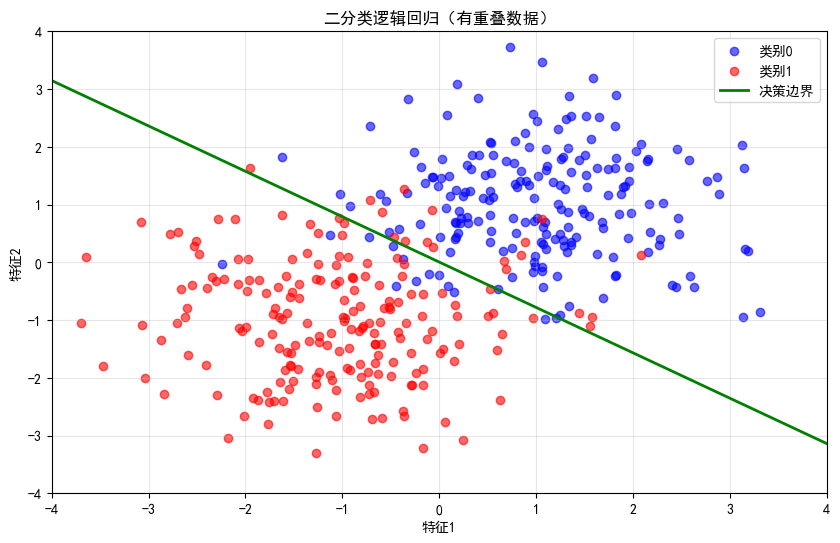


验证集准确率: 92.5%
测试集准确率: 87.0%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成两类数据（有重叠）
np.random.seed(42)
X0 = np.random.randn(200, 2) + [1, 1]      # 类别0
X1 = np.random.randn(200, 2) + [-1, -1]    # 类别1
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(200), np.ones(200)])

# 打乱数据
idx = np.random.permutation(400)
X_train, y_train = X[idx[:320]], y[idx[:320]]
X_val, y_val = X[idx[320:]], y[idx[320:]]

# 2. sigmoid和交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-15
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 3. 梯度下降训练
w = np.random.randn(2) * 0.01
b = 0.0
lr = 0.1

for i in range(1000):
    # 前向
    z = X_train @ w + b
    y_pred = sigmoid(z)
    
    # 反向更新
    dz = y_pred - y_train
    w -= lr * (X_train.T @ dz) / len(y_train)
    b -= lr * dz.mean()
    
    if (i+1) % 200 == 0:
        loss = binary_cross_entropy(y_pred, y_train)
        # 计算训练准确率
        train_acc = np.mean((y_pred >= 0.5) == y_train)
        print(f"迭代 {i+1}, 损失: {loss:.4f}, 训练准确率: {train_acc*100:.1f}%")

# 4. 绘制决策边界
plt.figure(figsize=(10, 6))
plt.scatter(X0[:,0], X0[:,1], c='blue', alpha=0.6, label='类别0')
plt.scatter(X1[:,0], X1[:,1], c='red', alpha=0.6, label='类别1')

# 决策边界
x1 = np.linspace(-4, 4, 100)
x2 = -(w[0]*x1 + b) / w[1]
plt.plot(x1, x2, 'g-', linewidth=2, label='决策边界')

plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('二分类逻辑回归（有重叠数据）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.show()

# 验证集准确率
y_val_pred = (sigmoid(X_val @ w + b) >= 0.5).astype(int)
val_acc = np.mean(y_val_pred == y_val)
print(f"\n验证集准确率: {val_acc*100:.1f}%")

# 测试集（新生成100个样本）
X_test0 = np.random.randn(50, 2) + [1, 1]
X_test1 = np.random.randn(50, 2) + [-1, -1]
X_test = np.vstack([X_test0, X_test1])
y_test = np.hstack([np.zeros(50), np.ones(50)])

y_test_pred = (sigmoid(X_test @ w + b) >= 0.5).astype(int)
test_acc = np.mean(y_test_pred == y_test)
print(f"测试集准确率: {test_acc*100:.1f}%")